In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

lineups = pd.read_parquet("../data/raw/lineups.parquet")
events = pd.read_parquet("../data/raw/events.parquet")

FULLBACK_LABELS = [
    "Left Back",
    "Right Back",
    "Left Wing Back",
    "Right Wing Back"
]

DEFENSIVE_MIDFIELD_LABELS = [
    "Center Defensive Midfield",
    "Left Defensive Midfield",
    "Right Defensive Midfield"
]

CREATIVE_MIDFIELD_LABELS = [
    "Center Midfield",
    "Left Midfield",
    "Right Midfield",
    "Left Center Midfield",
    "Right Center Midfield",
    "Center Attacking Midfield",
    "Left Attacking Midfield",
    "Right Attacking Midfield"
]

def extract_positions(position_history):
    if not isinstance(position_history, (list, tuple, np.ndarray)):
        return []
    
    return [
        stint["position"]
        for stint in position_history
        if isinstance(stint, dict) and "position" in stint
    ]

lineups["position_list"] = (
    lineups["positions"].apply(extract_positions)
)

positions_long = (
    lineups[
        [
            "player_id",
            "player_name",
            "position_list"
        ]
    ]
    .explode("position_list")
    .rename(columns={"position_list": "position"})
    .dropna(subset=["position"])
)

print(positions_long.shape)

print(
    sorted(
        positions_long["position"].unique()
    )
)

(13609, 3)
['Center Attacking Midfield', 'Center Back', 'Center Defensive Midfield', 'Center Forward', 'Center Midfield', 'Goalkeeper', 'Left Attacking Midfield', 'Left Back', 'Left Center Back', 'Left Center Forward', 'Left Center Midfield', 'Left Defensive Midfield', 'Left Midfield', 'Left Wing', 'Left Wing Back', 'Right Attacking Midfield', 'Right Back', 'Right Center Back', 'Right Center Forward', 'Right Center Midfield', 'Right Defensive Midfield', 'Right Midfield', 'Right Wing', 'Right Wing Back']


In [2]:
position_counts = (
    positions_long
    .groupby(
        [
            "player_id",
            "player_name",
            "position"
        ]
    )
    .size()
    .reset_index(name="appearances")
)


player_totals = (
    position_counts
    .groupby(
        [
            "player_id",
            "player_name"
        ]
    )["appearances"]
    .sum()
    .reset_index(name="total_appearances")
)


lineup_position_shares = (
    position_counts
    .merge(
        player_totals,
        on=["player_id", "player_name"]
    )
)

lineup_position_shares["position_share"] = (
    lineup_position_shares["appearances"]
    / lineup_position_shares["total_appearances"]
)

In [3]:
sorted(events["position"].dropna().unique())

position_counts = (
    events
    .dropna(subset=["player_id", "position"])
    .groupby(
        ["player_id", "player", "position"]
    )
    .size()
    .reset_index(name="events")
)

player_totals = (
    position_counts
    .groupby(["player_id", "player"])["events"]
    .sum()
    .reset_index(name="total_events")
)

event_position_shares = position_counts.merge(
    player_totals,
    on=["player_id", "player"]
)

event_position_shares["position_share"] = (
    event_position_shares["events"]
    / event_position_shares["total_events"]
)

In [4]:
ROLE_LABELS = {
    "Full Back": FULLBACK_LABELS,
    "Defensive Midfielder": DEFENSIVE_MIDFIELD_LABELS,
    "Creative Midfielder": CREATIVE_MIDFIELD_LABELS
}


def get_role_shares(
    shares_df,
    labels,
    player_col
):
    return (
        shares_df[
            shares_df["position"]
            .isin(labels)
        ]
        .groupby(
            [
                "player_id",
                player_col
            ],
            as_index=False
        )["position_share"]
        .sum()
        .rename(
            columns={
                player_col: "player_name"
            }
        )
    )

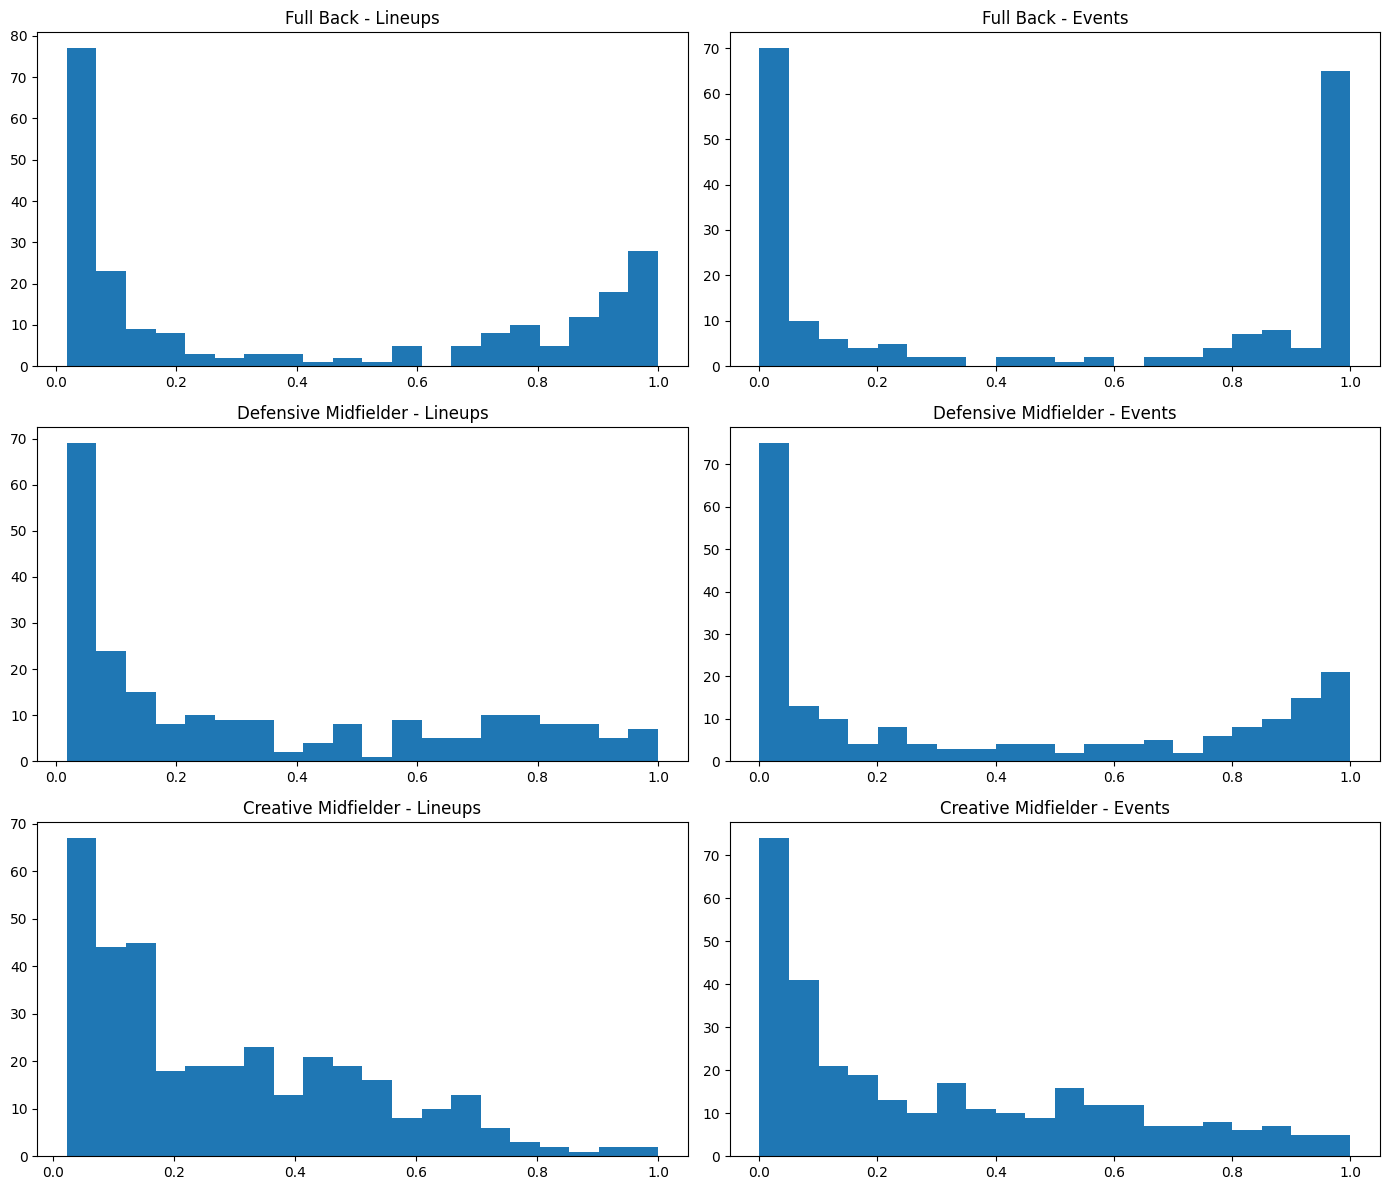

In [5]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 12)
)

for row, (
    role_name,
    labels
) in enumerate(
    ROLE_LABELS.items()
):

    lineup_role = get_role_shares(
        lineup_position_shares,
        labels,
        "player_name"
    )

    event_role = get_role_shares(
        event_position_shares,
        labels,
        "player"
    )

    axes[row, 0].hist(
        lineup_role["position_share"],
        bins=20
    )

    axes[row, 0].set_title(
        f"{role_name} - Lineups"
    )

    axes[row, 1].hist(
        event_role["position_share"],
        bins=20
    )

    axes[row, 1].set_title(
        f"{role_name} - Events"
    )

plt.tight_layout()
plt.show()

In [6]:
for role_name, labels in ROLE_LABELS.items():

    print("\n")
    print("=" * 60)
    print(role_name.upper())
    print("=" * 60)

    lineup_role = get_role_shares(
        lineup_position_shares,
        labels,
        "player_name"
    )

    event_role = get_role_shares(
        event_position_shares,
        labels,
        "player"
    )

    print("\nLINEUPS")
    print(
        lineup_role["position_share"]
        .describe()
        .round(3)
    )

    print("\nEVENTS")
    print(
        event_role["position_share"]
        .describe()
        .round(3)
    )



FULL BACK

LINEUPS
count    223.000
mean       0.414
std        0.395
min        0.019
25%        0.047
50%        0.194
75%        0.863
max        1.000
Name: position_share, dtype: float64

EVENTS
count    198.000
mean       0.484
std        0.445
min        0.001
25%        0.016
50%        0.380
75%        0.983
max        1.000
Name: position_share, dtype: float64


DEFENSIVE MIDFIELDER

LINEUPS
count    226.000
mean       0.333
std        0.319
min        0.018
25%        0.052
50%        0.205
75%        0.625
max        1.000
Name: position_share, dtype: float64

EVENTS
count    205.000
mean       0.378
std        0.385
min        0.000
25%        0.014
50%        0.211
75%        0.808
max        1.000
Name: position_share, dtype: float64


CREATIVE MIDFIELDER

LINEUPS
count    351.000
mean       0.285
std        0.227
min        0.022
25%        0.087
50%        0.222
75%        0.449
max        1.000
Name: position_share, dtype: float64

EVENTS
count    310.000
mean      

In [7]:
LOWER = 0.50
UPPER = 0.80

for role_name, labels in ROLE_LABELS.items():

    print("\n")
    print("=" * 60)
    print(role_name.upper())
    print("=" * 60)

    lineup_role = (
        get_role_shares(
            lineup_position_shares,
            labels,
            "player_name"
        )
        .rename(
            columns={
                "position_share": "lineup_share"
            }
        )
    )

    event_role = (
        get_role_shares(
            event_position_shares,
            labels,
            "player"
        )
        .rename(
            columns={
                "position_share": "event_share"
            }
        )
    )

    comparison = (
        lineup_role
        .merge(
            event_role,
            on=[
                "player_id",
                "player_name"
            ],
            how="outer"
        )
        .fillna(0)
    )

    borderline = comparison[
        (
            comparison["lineup_share"]
            .between(
                LOWER,
                UPPER
            )
        )
        |
        (
            comparison["event_share"]
            .between(
                LOWER,
                UPPER
            )
        )
    ]

    display(
        borderline.sort_values(
            "event_share",
            ascending=False
        )
    )



FULL BACK


,player_id,player_name,lineup_share,event_share
203,27155,Bojan Jokić,0.666667,1.000000
161,23800,Laureano Sanabria Ruiz,0.785714,0.983485
154,20215,Álvaro Arbeloa Coca,0.555556,0.980040
121,7577,Carles Planas Antolínez,0.766667,0.971462
12,4788,Jesús Gámez Duarte,0.769231,0.970111
87,6776,David Juncà Reñé,0.800000,0.959667
191,26633,Alberto Lora Ramos,0.785714,0.951954
74,6718,Sergio Escudero Palomo,0.736842,0.883341
63,6672,Jorge Andújar Moreno,0.782609,0.882595
170,24138,Joaquín José Marín Ruiz,0.705882,0.881103




DEFENSIVE MIDFIELDER


,player_id,player_name,lineup_share,event_share
157,18904,Claudio Matías Kranevitter,0.769231,1.000000
165,21229,Sergi Samper Montaña,0.500000,1.000000
106,6834,Gerard Gumbau Garriga,0.666667,0.988506
20,5539,Carlos Henrique Casimiro,0.800000,0.979407
93,6765,Rodrigo Hernández Cascante,0.750000,0.976190
43,6388,Ander Iturraspe Derteano,0.800000,0.964739
222,27526,Rachid Aït-Atmane,0.666667,0.951385
60,6633,Markel Bergara Larrañaga,0.760000,0.928571
155,18407,José Alberto Cañas Ruiz Herrera,0.705882,0.910069
44,6389,Mikel San José Domínguez,0.734694,0.907747




CREATIVE MIDFIELDER


,player_id,player_name,lineup_share,event_share
166,6840,Marcos Llorente Moreno,0.666667,1.000000
137,6737,Alfonso Pedraza Sag,0.666667,0.937500
70,6391,Raúl García Escudero,0.687500,0.928771
36,5504,Éver Maximiliano David Banega,0.742857,0.891034
81,6563,Juan Pablo Añor Acosta,0.763158,0.886022
...,...,...,...,...
270,23943,Rubén García Santos,0.533333,0.454015
332,27345,Didier Digard,0.533333,0.401739
284,24453,Josip Radošević,0.500000,0.238926
350,197562,Iñigo Barrenetxea García,0.500000,0.192308


In [8]:
def find_player(name):

    for role_name, labels in ROLE_LABELS.items():

        lineup_role = (
            get_role_shares(
                lineup_position_shares,
                labels,
                "player_name"
            )
            .rename(
                columns={
                    "position_share": "lineup_share"
                }
            )
        )

        event_role = (
            get_role_shares(
                event_position_shares,
                labels,
                "player"
            )
            .rename(
                columns={
                    "position_share": "event_share"
                }
            )
        )

        comparison = (
            lineup_role
            .merge(
                event_role,
                on=[
                    "player_id",
                    "player_name"
                ],
                how="outer"
            )
            .fillna(0)
        )

        result = comparison[
            comparison["player_name"]
            .str.contains(
                name,
                case=False,
                na=False
            )
        ]

        if len(result) > 0:

            print(f"\n{role_name}")
            display(result)

In [12]:
find_player("Federico Ricca")
find_player("Borja Ekiza")
find_player("Jordi Alba")
find_player("James David Rodríguez")
find_player("Toni Kroos")


Full Back


,player_id,player_name,lineup_share,event_share
103,6844,Federico Ricca Rostagnol,1.0,1.0



Full Back


,player_id,player_name,lineup_share,event_share
194,26736,Borja Ekiza Imaz,0.6,0.767528



Full Back


...

,player_id,player_name,lineup_share,event_share
47,5695,James David Rodríguez Rubio,0.5,0.574977



Defensive Midfielder


,player_id,player_name,lineup_share,event_share
21,5574,Toni Kroos,0.65,0.66696



Creative Midfielder


,player_id,player_name,lineup_share,event_share
40,5574,Toni Kroos,0.35,0.33304


### Position Threshold Review

Position-share thresholds were selected through exploratory analysis of the full-back, defensive midfielder, and creative midfielder populations.

Both lineup data and event data were evaluated. Histograms were used to inspect the distribution of position shares, while borderline player-seasons were manually reviewed to understand how threshold choices affected population membership.

The objective was not to determine a player's "true" position, but to construct comparison populations that predominantly represent the intended tactical role.

Special attention was given to player-seasons near candidate thresholds and to disagreement cases between lineup-based and event-based position shares. These cases often represent hybrid roles, positional flexibility, or tactical adaptations within a season.

Selected thresholds:

* Full Back: 0.6
* Defensive Midfielder: 0.5
* Creative Midfielder: 0.5

Several edge cases were identified during the review process. Some players classified into a role population may be known primarily for a different position outside the dataset. Rather than automatically excluding these observations, they were retained when the season-level data indicated substantial role occupancy.

This highlights an important limitation of recruitment analysis. Event data can identify statistical profiles and role occupancy, but it cannot fully capture contextual factors such as coaching decisions, squad depth, tactical constraints, positional versatility, or a player's long-term career profile. As a result, statistical outputs should be treated as decision-support tools rather than standalone recruitment decisions.

The final role populations are therefore intended to provide structured comparison groups for further performance evaluation, not definitive statements about a player's natural position.


In [5]:
population = pd.read_parquet("../data/processed/player_populations.parquet")

population.info()
population.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         255 non-null    int64  
 1   player_name       255 non-null    str    
 2   competition_name  255 non-null    str    
 3   season            255 non-null    str    
 4   role              255 non-null    str    
 5   lineup_share      255 non-null    float64
 6   event_share       255 non-null    float64
dtypes: float64(2), int64(1), str(4)
memory usage: 27.7 KB


,player_id,player_name,competition_name,season,role,lineup_share,event_share
0,27148,Abraham González Casanova,La Liga,2015/2016,Creative Midfielder,0.428571,0.595404
1,6557,Adrián González Morales,La Liga,2015/2016,Creative Midfielder,0.581395,0.653197
2,6926,Alen Halilović,La Liga,2015/2016,Creative Midfielder,0.563636,0.655665
3,6737,Alfonso Pedraza Sag,La Liga,2015/2016,Creative Midfielder,0.666667,0.937500
4,10802,André Filipe Tavares Gomes,La Liga,2015/2016,Creative Midfielder,0.775510,0.857961
5,5216,Andrés Iniesta Luján,La Liga,2015/2016,Creative Midfielder,0.970588,0.999843
6,16073,Aras Özbiliz,La Liga,2015/2016,Creative Midfielder,0.400000,0.530201
7,11094,Arda Turan,La Liga,2015/2016,Creative Midfielder,0.900000,0.921754
8,3601,Charly Musonda Junior,La Liga,2015/2016,Creative Midfielder,0.428571,0.572634
9,3084,Christian Atsu Twasam,La Liga,2015/2016,Creative Midfielder,0.750000,0.863768


In [4]:
population[
    population["player_name"]
    .str.contains(
        "Toni Kroos|Jordi Alba|James|Luka Modrić|Sergio Busquets|Andrés Iniesta",
        case=False,
        na=False,
    )
].sort_values(
    "role",
    ascending=False,
)

,player_id,player_name,competition_name,season,role,lineup_share,event_share
215,5211,Jordi Alba Ramos,La Liga,2015/2016,Full Back,0.969697,1.000000
148,5203,Sergio Busquets i Burgos,La Liga,2015/2016,Defensive Midfielder,0.846154,0.915124
154,5574,Toni Kroos,La Liga,2015/2016,Defensive Midfielder,0.650000,0.666960
5,5216,Andrés Iniesta Luján,La Liga,2015/2016,Creative Midfielder,0.970588,0.999843
26,5695,James David Rodríguez Rubio,La Liga,2015/2016,Creative Midfielder,0.500000,0.574977
48,5463,Luka Modrić,La Liga,2015/2016,Creative Midfielder,0.717949,0.769700


In [7]:
population.groupby("role").size()

role
Creative Midfielder     85
Defensive Midfielder    77
Full Back               93
dtype: int64